# Baseline Evaluation

Ranking-style evaluation of simple baselines on LOB features.
Split by full UTC calendar days with purge at boundaries.
All configured horizons evaluated on the same split.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRegressor

from src.analysis.io import load_dataset_with_meta
from src.analysis.market_context import attach_segment_id, label_profile
from src.analysis.baseline_eval import (
    full_utc_days, split_by_utc_days,
    bucket_analysis, tail_stats, coverage_edge_sweep, eval_summary,
)
from src.dataset.schema import FEATURE_COLUMNS, LABEL_COL

pd.set_option("display.float_format", "{:.6f}".format)
pd.set_option("display.max_columns", 20)
%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 4)

/Users/efremtsevv/scripts/hft/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [2]:
DS_DIR = Path("../data/datasets/binance/BTCUSDT_v2")

HORIZONS = {
    500:  DS_DIR / "dataset_d4D_i100_tw1000_w600_h500.parquet",
    1000: DS_DIR / "dataset_d4D_i100_tw1000_w600_h1000.parquet",
    2000: DS_DIR / "dataset_d4D_i100_tw1000_w600_h2000.parquet",
    5000: DS_DIR / "dataset_d4D_i100_tw1000_w600_h5000.parquet",
    10000: DS_DIR / "dataset_d4D_i100_tw1000_w600_h10000.parquet",
}

REF_PRICE = 69_492.49

# Number of full UTC days for each split (sequential).
TRAIN_DAYS = 1
VAL_DAYS = 1
TEST_DAYS = 1

## Load & split

Only full UTC calendar days are used. Partial first/last days are dropped.
Purge removes rows from the tail of each split whose label window crosses the boundary.

In [3]:
def load(horizon_ms: int) -> tuple[pd.DataFrame, dict]:
    df, meta = load_dataset_with_meta(HORIZONS[horizon_ms])
    attach_segment_id(df, int(meta["interval_ms"]))
    return df, meta


def make_split(df, horizon_ms):
    days = full_utc_days(df)
    need = TRAIN_DAYS + VAL_DAYS + TEST_DAYS
    print(f"Full UTC days: {days}  (need {need})")
    assert len(days) >= need, f"Need {need} full days, have {len(days)}"
    t = days[:TRAIN_DAYS]
    v = days[TRAIN_DAYS:TRAIN_DAYS + VAL_DAYS]
    s = days[TRAIN_DAYS + VAL_DAYS:TRAIN_DAYS + VAL_DAYS + TEST_DAYS]
    print(f"train={t}  val={v}  test={s}")
    return split_by_utc_days(df, t, v, s, horizon_ms)

In [4]:
# Load and split all horizons
data = {}  # h_ms -> {"parts": ..., "h": ..., "meta": ...}

for h_ms, path in HORIZONS.items():
    df, meta = load(h_ms)
    h = int(meta["horizon_ms"])
    parts = make_split(df, h)
    data[h_ms] = {"parts": parts, "h": h}
    print()

Full UTC days: [datetime.date(2026, 3, 24), datetime.date(2026, 3, 25), datetime.date(2026, 3, 26)]  (need 3)
train=[datetime.date(2026, 3, 24)]  val=[datetime.date(2026, 3, 25)]  test=[datetime.date(2026, 3, 26)]
  Purged 5 rows from train tail
  Purged 5 rows from val tail
train:    835,177 rows  [2026-03-24 00:00:00+00:00 → 2026-03-24 23:59:59.400000+00:00]
  val:    845,059 rows  [2026-03-25 00:00:00+00:00 → 2026-03-25 23:59:59.400000+00:00]
 test:    864,000 rows  [2026-03-26 00:00:00+00:00 → 2026-03-26 23:59:59.900000+00:00]

Full UTC days: [datetime.date(2026, 3, 24), datetime.date(2026, 3, 25), datetime.date(2026, 3, 26)]  (need 3)
train=[datetime.date(2026, 3, 24)]  val=[datetime.date(2026, 3, 25)]  test=[datetime.date(2026, 3, 26)]
  Purged 10 rows from train tail
  Purged 10 rows from val tail
train:    835,157 rows  [2026-03-24 00:00:00+00:00 → 2026-03-24 23:59:58.900000+00:00]
  val:    845,039 rows  [2026-03-25 00:00:00+00:00 → 2026-03-25 23:59:58.900000+00:00]
 test:    

In [5]:
# Label distributions
for h_ms, d in data.items():
    print(f"\n{'='*40}  h{h_ms}")
    for name in ["train", "val", "test"]:
        lp = label_profile(d["parts"][name])
        print(f"\n--- {name} ({len(d['parts'][name]):,} rows) ---")
        print(lp.to_string())


========================================  h500

--- train (835,177 rows) ---
column          label
count          835177
mean        -0.003290
std          3.390091
min        -92.205000
p5          -4.250000
p25          0.000000
median       0.000000
p75          0.000000
p95          4.270000
max         91.615000
zero_pct     0.815932
pos_pct      0.091202
neg_pct      0.092865

--- val (845,059 rows) ---
column          label
count          845059
mean         0.005101
std          3.123686
min        -96.650000
p5          -2.700000
p25          0.000000
median       0.000000
p75          0.000000
p95          2.700000
max        315.900000
zero_pct     0.858851
pos_pct      0.070032
neg_pct      0.071117

--- test (864,000 rows) ---
column           label
count           864000
mean         -0.014551
std           3.097459
min        -195.540000
p5           -2.810000
p25           0.000000
median        0.000000
p75           0.000000
p95           2.850000
max         140.675

## Baselines

In [6]:
class SingleFeatureBaseline:
    def __init__(self, feature: str):
        self.feature = feature
        self.name = feature
    def fit(self, X, y): return self
    def predict(self, X): return X[self.feature].values


class RidgeBaseline:
    def __init__(self, alpha=1.0):
        self.scaler = StandardScaler()
        self.model = Ridge(alpha=alpha)
        self.name = f"Ridge(a={alpha})"
    def fit(self, X, y):
        self.scaler.fit(X[FEATURE_COLUMNS])
        self.model.fit(self.scaler.transform(X[FEATURE_COLUMNS]), y)
        return self
    def predict(self, X):
        return self.model.predict(self.scaler.transform(X[FEATURE_COLUMNS]))


class CatBoostBaseline:
    def __init__(self, n_estimators=500):
        self.model = CatBoostRegressor(n_estimators=n_estimators, silent=True)
        self.name = f"CatBoost({n_estimators})"
    def fit(self, X, y):
        self.model.fit(X[FEATURE_COLUMNS], y)
        return self
    def predict(self, X):
        return self.model.predict(X[FEATURE_COLUMNS])


BASELINE_FACTORIES = [
    lambda: SingleFeatureBaseline("microprice_minus_mid"),
    lambda: SingleFeatureBaseline("imbalance_1"),
    lambda: RidgeBaseline(alpha=1.0),
    lambda: CatBoostBaseline(n_estimators=1000),
]

## Val evaluation — all horizons

In [7]:
def run_eval(parts, horizon_ms):
    bls = [f() for f in BASELINE_FACTORIES]
    train, val = parts["train"], parts["val"]
    scores = {}
    for bl in bls:
        bl.fit(train, train[LABEL_COL])
        scores[bl.name] = bl.predict(val)
    label = val[LABEL_COL].values
    summary = eval_summary(scores, label, REF_PRICE, horizon_ms)
    return bls, scores, label, summary


# Run eval for all horizons
results = {}  # h_ms -> {"bls", "scores", "label", "summary"}

for h_ms, d in data.items():
    bls, scores, label, summary = run_eval(d["parts"], d["h"])
    results[h_ms] = {"bls": bls, "scores": scores, "label": label, "summary": summary}
    display(summary)
    print()

Summary — h=500ms


,rank_IC,top10_bps,bot10_bps,top5_bps,bot5_bps,best_edge_bps_5cov
baseline,,,,,,
microprice_minus_mid,0.387367,0.253468,-0.249360,0.363105,-0.351109,0.357280
imbalance_1,0.387235,0.252273,-0.248395,0.360154,-0.349382,0.450221
Ridge(a=1.0),0.385547,0.261472,-0.256183,0.365913,-0.353763,0.424084
CatBoost(1000),0.391028,0.272974,-0.268256,0.387134,-0.376302,0.381073



Summary — h=1000ms


,rank_IC,top10_bps,bot10_bps,top5_bps,bot5_bps,best_edge_bps_5cov
baseline,,,,,,
microprice_minus_mid,0.419180,0.395047,-0.385365,0.538831,-0.510832,0.642566
imbalance_1,0.419140,0.394137,-0.384858,0.536545,-0.510153,0.523538
Ridge(a=1.0),0.417339,0.404148,-0.392392,0.538764,-0.507835,0.596784
CatBoost(1000),0.418961,0.411156,-0.402461,0.550513,-0.534730,0.679618



Summary — h=2000ms


,rank_IC,top10_bps,bot10_bps,top5_bps,bot5_bps,best_edge_bps_5cov
baseline,,,,,,
microprice_minus_mid,0.419270,0.572157,-0.562415,0.752646,-0.708921,0.860529
imbalance_1,0.419336,0.571221,-0.562729,0.751299,-0.710546,0.858571
Ridge(a=1.0),0.418174,0.583816,-0.571831,0.750310,-0.708044,0.717068
CatBoost(1000),0.413653,0.585109,-0.570782,0.738462,-0.724170,0.862508



Summary — h=5000ms


,rank_IC,top10_bps,bot10_bps,top5_bps,bot5_bps,best_edge_bps_5cov
baseline,,,,,,
microprice_minus_mid,0.357308,0.819842,-0.788715,1.040253,-0.941362,1.098036
imbalance_1,0.357357,0.817874,-0.789479,1.038241,-0.944005,0.990805
Ridge(a=1.0),0.356698,0.831281,-0.801773,1.027975,-0.941303,1.075152
CatBoost(1000),0.346260,0.795428,-0.759381,0.957965,-0.872512,1.006698



Summary — h=10000ms


,rank_IC,top10_bps,bot10_bps,top5_bps,bot5_bps,best_edge_bps_5cov
baseline,,,,,,
microprice_minus_mid,0.278753,0.963722,-0.903120,1.196556,-1.050973,1.180527
imbalance_1,0.278786,0.960971,-0.904085,1.194932,-1.054491,1.126496
Ridge(a=1.0),0.278616,0.974209,-0.929770,1.178108,-1.061366,1.115882
CatBoost(1000),0.265172,0.905288,-0.824072,1.046100,-0.930418,1.033017


## Bucket analysis (val)

In [8]:
for h_ms, r in results.items():
    for bl_name, sc in r["scores"].items():
        print(f"\n{'='*50}  h{h_ms} / {bl_name}")
        display(bucket_analysis(sc, r["label"], REF_PRICE))


==================================================  h500 / microprice_minus_mid


,count,mean_label,mean_label_bps,p_up,p_down
bucket,,,,,
0,84507,-1.732866,-0.249360,0.009100,0.327582
1,84505,-0.617477,-0.088855,0.010851,0.129330
2,84506,-0.360239,-0.051839,0.015691,0.084870
3,84506,-0.160341,-0.023073,0.021490,0.052789
4,84506,-0.027979,-0.004026,0.028045,0.035678
5,84512,0.039779,0.005724,0.034610,0.027026
6,84506,0.189295,0.027240,0.051712,0.021135
7,84499,0.374677,0.053916,0.082332,0.014521
8,84506,0.584789,0.084151,0.122666,0.010532



==================================================  h500 / imbalance_1


,count,mean_label,mean_label_bps,p_up,p_down
bucket,,,,,
0,84506,-1.726162,-0.248395,0.008686,0.326900
1,84506,-0.622507,-0.089579,0.010946,0.129636
2,84506,-0.360110,-0.051820,0.015810,0.084858
3,84507,-0.161772,-0.023279,0.021572,0.053073
4,84505,-0.028362,-0.004081,0.028164,0.035785
5,84505,0.042692,0.006143,0.034720,0.027052
6,84506,0.190355,0.027392,0.051890,0.021277
7,84506,0.376789,0.054220,0.082515,0.014591
8,84507,0.586950,0.084462,0.122759,0.010603



==================================================  h500 / Ridge(a=1.0)


...

,count,mean_label,mean_label_bps,p_up,p_down
bucket,,,,,
0,84468,-6.282710,-0.904085,0.248366,0.659481
1,84469,-3.716393,-0.534791,0.273745,0.550995
2,84469,-2.918553,-0.419981,0.286567,0.511762
3,84466,-1.529771,-0.220135,0.308112,0.440923
4,84469,-0.362496,-0.052163,0.339142,0.376126
5,84468,0.511140,0.073553,0.370259,0.347114
6,84466,1.990330,0.286409,0.435761,0.302619
7,84473,2.928801,0.421456,0.504339,0.272359
8,84463,3.704469,0.533075,0.562045,0.258669



==================================================  h10000 / Ridge(a=1.0)


,count,mean_label,mean_label_bps,p_up,p_down
bucket,,,,,
0,84468,-6.461201,-0.929770,0.250734,0.659848
1,84468,-3.789156,-0.545261,0.273346,0.550587
2,84469,-2.815511,-0.405153,0.286531,0.511087
3,84471,-1.512849,-0.217700,0.309680,0.441666
4,84464,-0.350459,-0.050431,0.340784,0.379392
5,84468,0.563713,0.081119,0.372721,0.340377
6,84467,2.000304,0.287845,0.436964,0.303775
7,84470,2.851524,0.410336,0.492222,0.271753
8,84466,3.746432,0.539113,0.569128,0.256221



==================================================  h10000 / CatBoost(1000)


,count,mean_label,mean_label_bps,p_up,p_down
bucket,,,,,
0,84468,-5.726683,-0.824072,0.263330,0.638751
1,84468,-3.932079,-0.565828,0.270753,0.550907
2,84468,-2.874158,-0.413593,0.286925,0.511247
3,84473,-1.432556,-0.206145,0.314136,0.433227
4,84464,-0.452218,-0.065074,0.340334,0.386899
5,84469,0.710628,0.102260,0.379607,0.341841
6,84474,1.919772,0.276256,0.443237,0.300850
7,84460,2.846883,0.409668,0.500580,0.270234
8,84467,3.652269,0.525563,0.548948,0.269371


## Tail analysis (val)

In [9]:
for h_ms, r in results.items():
    for bl_name, sc in r["scores"].items():
        print(f"\n{'='*50}  h{h_ms} / {bl_name}")
        display(tail_stats(sc, r["label"], REF_PRICE))


==================================================  h500 / microprice_minus_mid


,count,mean_label,mean_label_bps,mean_abs_label_bps,p_up,p_down
tail,,,,,,
bottom_5%,42253,-2.439942,-0.351109,0.373605,0.007431,0.445436
top_5%,42253,2.523308,0.363105,0.381085,0.445696,0.007573
bottom_10%,84507,-1.732866,-0.249360,0.271575,0.009100,0.327582
top_10%,84506,1.761410,0.253468,0.270892,0.323823,0.007704



==================================================  h500 / imbalance_1


,count,mean_label,mean_label_bps,mean_abs_label_bps,p_up,p_down
tail,,,,,,
bottom_5%,42253,-2.427944,-0.349382,0.368957,0.006532,0.444134
top_5%,42253,2.502799,0.360154,0.375970,0.444252,0.006769
bottom_10%,84506,-1.726162,-0.248395,0.269408,0.008686,0.326900
top_10%,84507,1.753108,0.252273,0.268877,0.323251,0.007396



==================================================  h500 / Ridge(a=1.0)


...

,count,mean_label,mean_label_bps,mean_abs_label_bps,p_up,p_down
tail,,,,,,
bottom_5%,42234,-7.327920,-1.054491,1.968526,0.230786,0.704882
top_5%,42234,8.303877,1.194932,2.056695,0.712791,0.225813
bottom_10%,84468,-6.282710,-0.904085,1.878018,0.248366,0.659481
top_10%,84468,6.678024,0.960971,1.887864,0.666986,0.238907



==================================================  h10000 / Ridge(a=1.0)


,count,mean_label,mean_label_bps,mean_abs_label_bps,p_up,p_down
tail,,,,,,
bottom_5%,42234,-7.375694,-1.061366,2.032335,0.243122,0.699058
top_5%,42234,8.186969,1.178108,2.132363,0.699792,0.240138
bottom_10%,84468,-6.461201,-0.929770,1.902745,0.250734,0.659848
top_10%,84468,6.770019,0.974209,1.931454,0.663210,0.244246



==================================================  h10000 / CatBoost(1000)


,count,mean_label,mean_label_bps,mean_abs_label_bps,p_up,p_down
tail,,,,,,
bottom_5%,42237,-6.465709,-0.930418,2.021650,0.262519,0.667732
top_5%,42234,7.269610,1.046100,2.119210,0.673391,0.254558
bottom_10%,84468,-5.726683,-0.824072,1.873414,0.263330,0.638751
top_10%,84468,6.291075,0.905288,1.931421,0.647476,0.255623


## Coverage vs edge (val)

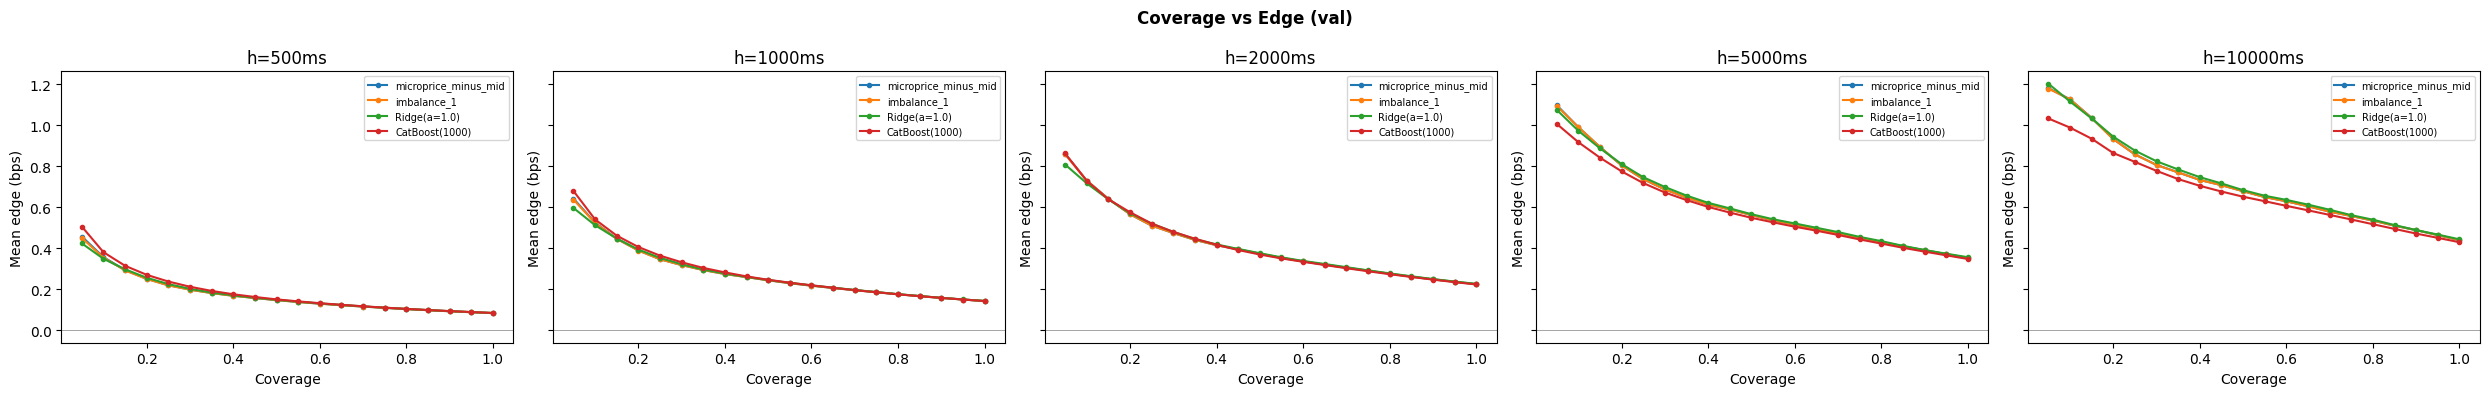

In [10]:
n_h = len(results)
fig, axes = plt.subplots(1, n_h, figsize=(5 * n_h, 4), sharey=True)
if n_h == 1:
    axes = [axes]

for ax, (h_ms, r) in zip(axes, results.items()):
    for bl_name, sc in r["scores"].items():
        ce = coverage_edge_sweep(sc, r["label"], REF_PRICE)
        ax.plot(ce["coverage"], ce["mean_edge_bps"], "o-", label=bl_name, markersize=3)
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_xlabel("Coverage")
    ax.set_ylabel("Mean edge (bps)")
    ax.set_title(f"h={h_ms}ms")
    ax.legend(fontsize=7)
fig.suptitle("Coverage vs Edge (val)", fontweight="bold")
fig.tight_layout()
plt.show()

## Decile comparison plot

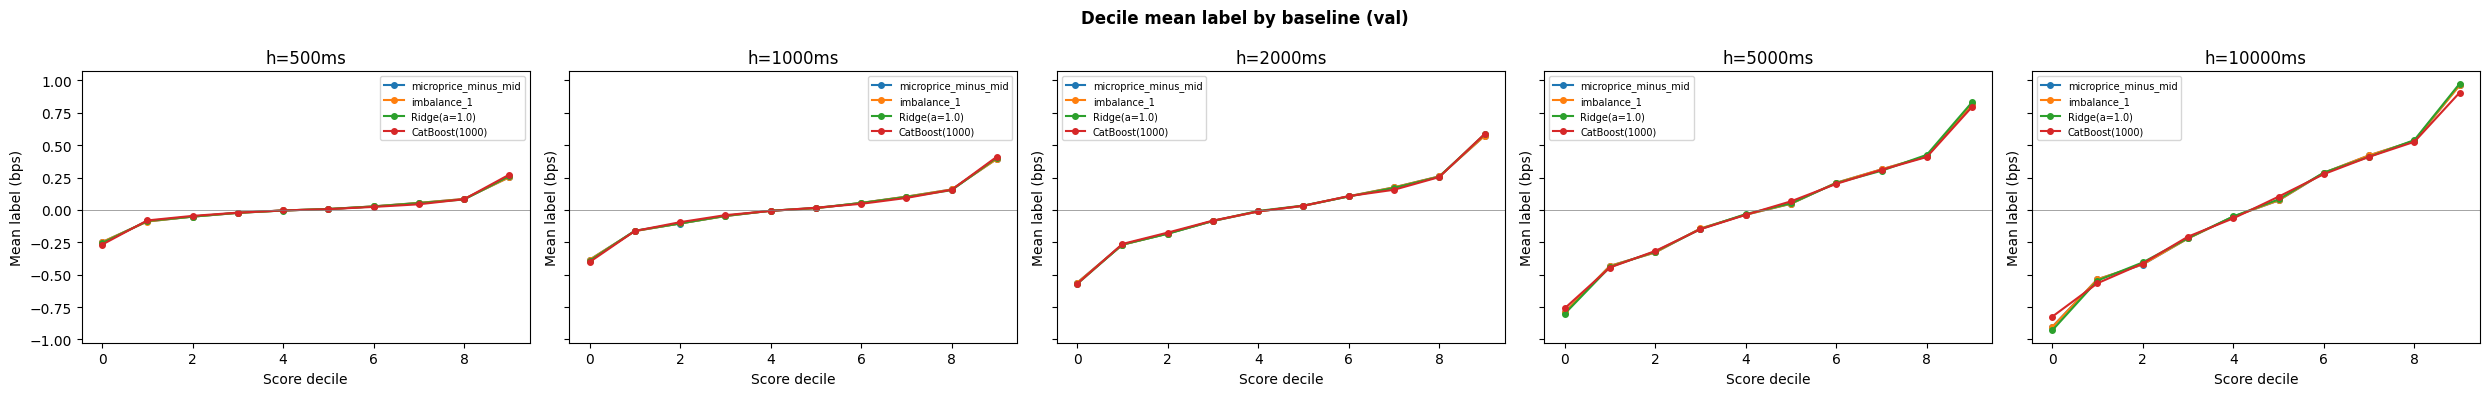

In [11]:
fig, axes = plt.subplots(1, n_h, figsize=(5 * n_h, 4), sharey=True)
if n_h == 1:
    axes = [axes]

for ax, (h_ms, r) in zip(axes, results.items()):
    label_arr = r["label"]
    for bl in r["bls"]:
        ba = bucket_analysis(bl.predict(data[h_ms]["parts"]["val"]), label_arr, REF_PRICE)
        ax.plot(ba.index, ba["mean_label_bps"], "o-", label=bl.name, markersize=4)
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_xlabel("Score decile")
    ax.set_ylabel("Mean label (bps)")
    ax.set_title(f"h={h_ms}ms")
    ax.legend(fontsize=7)
fig.suptitle("Decile mean label by baseline (val)", fontweight="bold")
fig.tight_layout()
plt.show()

## Test evaluation

Best baseline per horizon selected on val, then evaluated on held-out test.

In [12]:
for h_ms, r in results.items():
    parts = data[h_ms]["parts"]
    h = data[h_ms]["h"]
    best_name = r["summary"]["rank_IC"].idxmax()
    test_label = parts["test"][LABEL_COL].values
    test_scores = {bl.name: bl.predict(parts["test"]) for bl in r["bls"]}

    print(f"\n{'='*50}  h{h_ms}  (best on val: {best_name})")
    sum_test = eval_summary(test_scores, test_label, REF_PRICE, h)
    display(sum_test)

    print(f"\nBucket analysis on test — {best_name}")
    display(bucket_analysis(test_scores[best_name], test_label, REF_PRICE))

    print(f"\nTail stats on test — {best_name}")
    display(tail_stats(test_scores[best_name], test_label, REF_PRICE))


==================================================  h500  (best on val: CatBoost(1000))
Summary — h=500ms


,rank_IC,top10_bps,bot10_bps,top5_bps,bot5_bps,best_edge_bps_5cov
baseline,,,,,,
microprice_minus_mid,0.383251,0.234841,-0.238711,0.332783,-0.334255,0.429009
imbalance_1,0.383191,0.234748,-0.238440,0.331315,-0.331213,0.422871
Ridge(a=1.0),0.382275,0.242226,-0.250369,0.333808,-0.347765,0.334483
CatBoost(1000),0.388590,0.255551,-0.261472,0.358729,-0.364237,0.475777



Bucket analysis on test — CatBoost(1000)


,count,mean_label,mean_label_bps,p_up,p_down
bucket,,,,,
0,86400,-1.817037,-0.261472,0.016331,0.345382
1,86400,-0.558274,-0.080336,0.014896,0.127188
2,86401,-0.320801,-0.046163,0.012303,0.073425
3,86401,-0.185593,-0.026707,0.017523,0.053448
4,86402,-0.078043,-0.011230,0.023090,0.033946
5,86397,0.053008,0.007628,0.036008,0.025209
6,86399,0.168290,0.024217,0.055197,0.021065
7,86400,0.305376,0.043944,0.077951,0.013484
8,86400,0.511686,0.073632,0.125486,0.015150



Tail stats on test — CatBoost(1000)


...

,rank_IC,top10_bps,bot10_bps,top5_bps,bot5_bps,best_edge_bps_5cov
baseline,,,,,,
microprice_minus_mid,0.280461,0.817097,-0.921552,0.989937,-1.095947,1.178638
imbalance_1,0.280498,0.803190,-0.935275,0.958429,-1.122608,1.165468
Ridge(a=1.0),0.279122,0.815908,-0.937710,0.994924,-1.069292,1.090712
CatBoost(1000),0.264856,0.757989,-0.856031,0.890308,-0.985383,0.996782



Bucket analysis on test — imbalance_1


,count,mean_label,mean_label_bps,p_up,p_down
bucket,,,,,
0,86400,-6.499457,-0.935275,0.237049,0.660671
1,86400,-4.035810,-0.580755,0.257454,0.545185
2,86400,-3.502852,-0.504062,0.286366,0.500613
3,86400,-2.265333,-0.325982,0.329734,0.441574
4,86400,-0.417056,-0.060015,0.379225,0.384884
5,86400,0.453595,0.065272,0.411377,0.354826
6,86400,1.562143,0.224793,0.463449,0.318623
7,86400,2.636568,0.379403,0.527361,0.284167
8,86400,3.574196,0.514328,0.577581,0.262986



Tail stats on test — imbalance_1


,count,mean_label,mean_label_bps,mean_abs_label_bps,p_up,p_down
tail,,,,,,
bottom_5%,43200,-7.801281,-1.122608,1.896949,0.230069,0.699699
top_5%,43200,6.660364,0.958429,1.790019,0.714167,0.225880
bottom_10%,86400,-6.499457,-0.935275,1.736496,0.237049,0.660671
top_10%,86400,5.581568,0.803190,1.691073,0.667755,0.242546


## Research verdict

Automated summary. Criteria:
- **Ranking signal**: Spearman IC > 0.05 on both val and test
- **Tail concentration**: top5 − bottom5 spread > 0.1 bps
- **Test stability**: test/val IC ratio between 0.7 and 1.3
- **Horizon comparison**: direct IC comparison, no assumed winner

In [13]:
from scipy.stats import spearmanr

print("=" * 60)
print("RESEARCH VERDICT")
print("=" * 60)

verdict_rows = []

for h_ms, r in results.items():
    parts = data[h_ms]["parts"]
    best_name = r["summary"]["rank_IC"].idxmax()
    best_bl = next(b for b in r["bls"] if b.name == best_name)
    val_ic = r["summary"].loc[best_name, "rank_IC"]

    test_sc = best_bl.predict(parts["test"])
    test_lbl = parts["test"][LABEL_COL].values
    test_ic, _ = spearmanr(test_sc, test_lbl)

    ts_val = tail_stats(best_bl.predict(parts["val"]), r["label"], REF_PRICE)
    ts_test = tail_stats(test_sc, test_lbl, REF_PRICE)
    spread_val = ts_val.loc["top_5%", "mean_label_bps"] - ts_val.loc["bottom_5%", "mean_label_bps"]
    spread_test = ts_test.loc["top_5%", "mean_label_bps"] - ts_test.loc["bottom_5%", "mean_label_bps"]
    ic_ratio = test_ic / val_ic if val_ic != 0 else 0

    verdict_rows.append({
        "horizon": f"h{h_ms}",
        "best_baseline": best_name,
        "val_IC": val_ic,
        "test_IC": test_ic,
        "ratio": ic_ratio,
        "tail_spread_val_bps": spread_val,
        "tail_spread_test_bps": spread_test,
    })

    print(f"\n--- h{h_ms} ---")
    print(f"Best baseline: {best_name}")
    print(f"  val IC  = {val_ic:.4f}   test IC = {test_ic:.4f}   ratio = {ic_ratio:.3f}")
    print(f"  val tail spread = {spread_val:.4f} bps   test = {spread_test:.4f} bps")
    print(f"  Ranking signal:    {'YES' if val_ic > 0.05 and test_ic > 0.05 else 'NO'}")
    print(f"  Tail concentrated: {'YES' if spread_val > 0.1 and spread_test > 0.1 else 'NO'}")
    print(f"  Test stable:       {'YES' if 0.7 < ic_ratio < 1.3 else 'NO'}")

# Horizon comparison
print(f"\n--- Horizon comparison ---")
vdf = pd.DataFrame(verdict_rows).set_index("horizon")
display(vdf[["best_baseline", "val_IC", "test_IC", "tail_spread_val_bps"]])
best_h = vdf["val_IC"].idxmax()
print(f"\nStrongest ranking signal on val: {best_h} (IC={vdf.loc[best_h, 'val_IC']:.4f})")

RESEARCH VERDICT

--- h500 ---
Best baseline: CatBoost(1000)
  val IC  = 0.3910   test IC = 0.3886   ratio = 0.994
  val tail spread = 0.7634 bps   test = 0.7230 bps
  Ranking signal:    YES
  Tail concentrated: YES
  Test stable:       YES

--- h1000 ---
Best baseline: microprice_minus_mid
  val IC  = 0.4192   test IC = 0.4150   ratio = 0.990
  val tail spread = 1.0497 bps   test = 0.9677 bps
  Ranking signal:    YES
  Tail concentrated: YES
  Test stable:       YES

--- h2000 ---
Best baseline: imbalance_1
  val IC  = 0.4193   test IC = 0.4195   ratio = 1.000
  val tail spread = 1.4618 bps   test = 1.3267 bps
  Ranking signal:    YES
  Tail concentrated: YES
  Test stable:       YES

--- h5000 ---
Best baseline: imbalance_1
  val IC  = 0.3574   test IC = 0.3649   ratio = 1.021
  val tail spread = 1.9822 bps   test = 1.8257 bps
  Ranking signal:    YES
  Tail concentrated: YES
  Test stable:       YES

--- h10000 ---
Best baseline: imbalance_1
  val IC  = 0.2788   test IC = 0.2805   r

,best_baseline,val_IC,test_IC,tail_spread_val_bps
horizon,,,,
h500,CatBoost(1000),0.391028,0.388590,0.763436
h1000,microprice_minus_mid,0.419180,0.415010,1.049663
h2000,imbalance_1,0.419336,0.419517,1.461845
h5000,imbalance_1,0.357357,0.364912,1.982247
h10000,imbalance_1,0.278786,0.280498,2.249422



Strongest ranking signal on val: h2000 (IC=0.4193)
